# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import pickle

from unicodedata import normalize

# 1. Data exploration

In [2]:
df = pd.read_csv('/Users/festusattornelson/Documents/Projects/Python_Udemy/Projects/StudentPerformance/data/raw/student_dataset_10000_rows.csv')

In [3]:
df.shape

(10000, 8)

In [4]:
df.describe()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,5.989600,69.88460,6.498500,6.062600,9.988400,64.91100,86.704207
std,3.163589,17.61653,1.709354,3.138163,6.034145,17.50302,15.058383
min,1.000000,40.00000,4.000000,1.000000,0.000000,35.00000,26.670000
25%,3.000000,55.00000,5.000000,3.000000,5.000000,50.00000,76.727500
50%,6.000000,70.00000,6.500000,6.000000,10.000000,65.00000,92.120000
75%,9.000000,85.00000,8.000000,9.000000,15.000000,80.00000,100.000000
max,11.000000,100.00000,9.000000,11.000000,20.000000,95.00000,100.000000


In [5]:
df.isnull().sum()

study_hours              0
attendance               0
sleep_hours              0
internet_usage           0
assignments_completed    0
previous_score           0
exam_score               0
placement_status         0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            10000 non-null  int64  
 1   attendance             10000 non-null  int64  
 2   sleep_hours            10000 non-null  int64  
 3   internet_usage         10000 non-null  int64  
 4   assignments_completed  10000 non-null  int64  
 5   previous_score         10000 non-null  int64  
 6   exam_score             10000 non-null  float64
 7   placement_status       10000 non-null  object 
dtypes: float64(1), int64(6), object(1)
memory usage: 625.1+ KB


In [7]:
df.duplicated().sum()

np.int64(0)

# 2. EDA and reporting

In [8]:
# create output directory
output_dir = "/Users/festusattornelson/Documents/Projects/Python_Udemy/Projects/StudentPerformance/visualizations"
os.makedirs(output_dir, exist_ok=True)

### correlation matrix

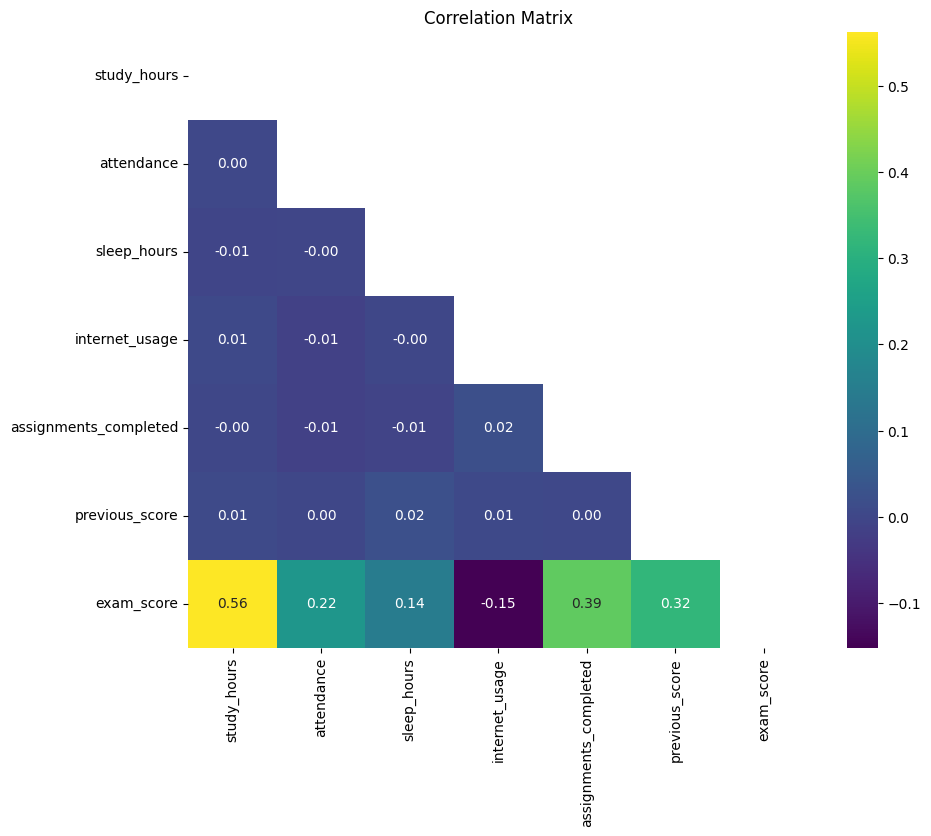

Graph saved to: /Users/festusattornelson/Documents/Projects/Python_Udemy/Projects/StudentPerformance/visualizations/correlation_matrix.png


In [9]:
correlation_matrix = df.select_dtypes(include=['float64', 'int64']).corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='viridis', fmt=".2f")
plt.title('Correlation Matrix')

# Save figure
save_path = os.path.join(output_dir, "correlation_matrix.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

print(f"Graph saved to: {save_path}")

### Placement Status Distribution

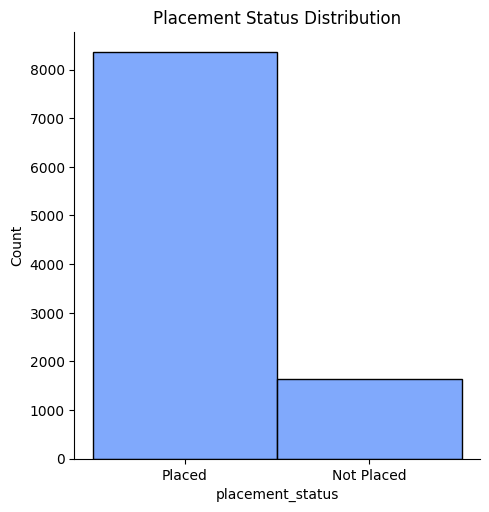

Graph saved to: /Users/festusattornelson/Documents/Projects/Python_Udemy/Projects/StudentPerformance/visualizations/placement_status_distribution.png


<Figure size 640x480 with 0 Axes>

In [10]:
sns.displot(df['placement_status'], kde=False)
plt.title('Placement Status Distribution')
plt.show()

save_path = os.path.join(output_dir, "placement_status_distribution.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')

print(f"Graph saved to: {save_path}")

### Exam Scores vs Placement Status

Graph saved to: /Users/festusattornelson/Documents/Projects/Python_Udemy/Projects/StudentPerformance/visualizations/placement_exam-scores.png


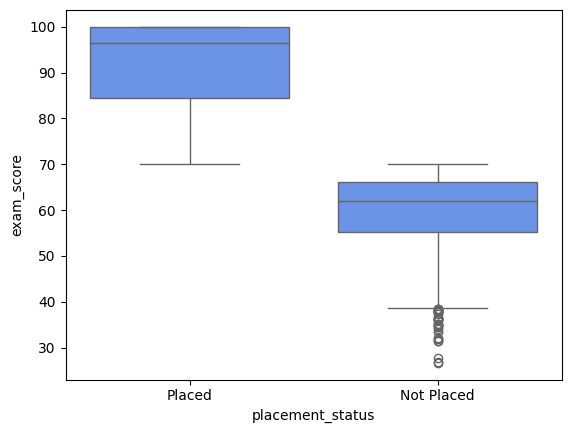

In [11]:
sns.boxplot(data=df, x='placement_status', y='exam_score')

save_path = os.path.join(output_dir, "placement_exam-scores.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')

print(f"Graph saved to: {save_path}")

### Exam scores vs Study hours

Graph saved to: /Users/festusattornelson/Documents/Projects/Python_Udemy/Projects/StudentPerformance/visualizations/exam-scores vs study-hours.png


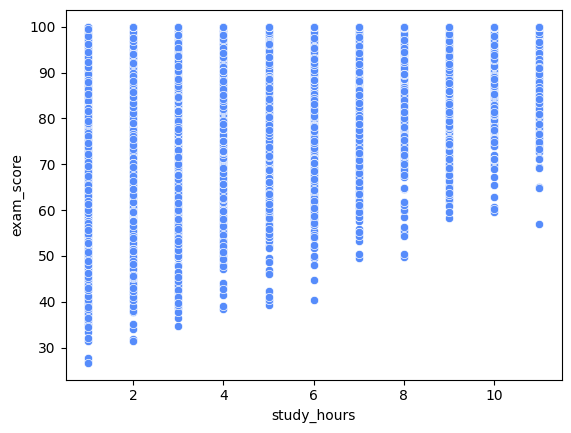

In [12]:
sns.scatterplot(data=df, y='exam_score', x='study_hours')

save_path = os.path.join(output_dir, "exam-scores vs study-hours.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')

print(f"Graph saved to: {save_path}")

In [13]:
df.placement_status.value_counts()

placement_status
Placed        8356
Not Placed    1644
Name: count, dtype: int64

In [15]:
df.placement_status.value_counts(normalize=True)

placement_status
Placed        0.8356
Not Placed    0.1644
Name: proportion, dtype: float64